In [5]:
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
# load results
header = ["SIMULATIONS", "SAMPLE_SIZE", "correct actions", "incorrect actions", "correct first step", "incorrect first step", "identical", "non-identical", 
          "non_unique_sequences", "first_step_not_in_actions", "fails"]

for i in range(0, 10):
    header.append(f'step_{i}_accuracy')
    header.append(f'step_{i}_occurrences')

pd.set_option('display.max_columns', None)
results = pd.read_csv("results.csv", names=header)
results

,SIMULATIONS,SAMPLE_SIZE,correct actions,incorrect actions,correct first step,incorrect first step,identical,non-identical,non_unique_sequences,first_step_not_in_actions,fails,step_0_accuracy,step_0_occurrences,step_1_accuracy,step_1_occurrences,step_2_accuracy,step_2_occurrences,step_3_accuracy,step_3_occurrences,step_4_accuracy,step_4_occurrences,step_5_accuracy,step_5_occurrences,step_6_accuracy,step_6_occurrences,step_7_accuracy,step_7_occurrences,step_8_accuracy,step_8_occurrences,step_9_accuracy,step_9_occurrences
0,300,39736,39584,98,39682,0,29989,9693,0,0,54,1.0,301,1.0,39381,0.970403,35645,0.908061,33968,0.847782,30292,0.783248,22934,0.678690,12393,0.477265,2969,1.0,139,NaN,NaN
1,300,39736,39580,98,39678,0,29982,9696,0,0,58,1.0,301,1.0,39377,0.970371,35641,0.907961,33964,0.847711,30291,0.783248,22934,0.678690,12393,0.477265,2969,1.0,139,NaN,NaN
2,300,39736,39583,98,39681,0,29987,9694,2,0,55,1.0,301,1.0,39380,0.970430,35644,0.908087,33967,0.847777,30291,0.783160,22934,0.678609,12393,0.477265,2969,1.0,139,NaN,NaN


In [7]:
# calculate mean and std for each metric and create a table
results_table = pd.DataFrame({
    "Correct": [results["correct actions"].mean(), results["correct first step"].mean(), results["identical"].mean()],
    "Incorrect": [results["incorrect actions"].mean(), results["incorrect first step"].mean(), results["non-identical"].mean()]
}, index=["Actions", "First step", "Identical"])

results_table["Correct"] = [f"{results[col].mean():.2f} ± {results[col].std():.2f}" for col in ["correct actions", "correct first step", "identical"]]
results_table["Incorrect"] = [f"{results[col].mean():.2f} ± {results[col].std():.2f}" for col in ["incorrect actions", "incorrect first step", "non-identical"]]

accuracies = {
    "Actions": pd.Series([
        row["correct actions"] / (row["correct actions"] + row["incorrect actions"]) * 100
        for _, row in results.iterrows()
        if row["correct actions"] + row["incorrect actions"] > 0
    ]),
    "First step": pd.Series([
        row["correct first step"] / (row["correct first step"] + row["incorrect first step"]) * 100
        for _, row in results.iterrows()
        if row["correct first step"] + row["incorrect first step"] > 0
    ]),
    "Identical": pd.Series([
        row["identical"] / (row["identical"] + row["non-identical"]) * 100
        for _, row in results.iterrows()
        if row["identical"] + row["non-identical"] > 0
    ])
}

results_table["Accuracy"] = [f"{accuracies[metric].mean():.2f} ± {accuracies[metric].std():.2f}" for metric in ["Actions", "First step", "Identical"]]
display(results_table)

# calculate fail rate
fail_rates = [
    row["fails"] / total * 100
    for _, row in results.iterrows()
    if (total := row["correct actions"] + row["incorrect actions"]) > 0
]

print(f"Fail rate: {pd.Series(fail_rates).mean():.2f} ± {pd.Series(fail_rates).std():.2f} [%]")

,Correct,Incorrect,Accuracy
Actions,39582.33 ± 2.08,98.00 ± 0.00,99.75 ± 0.00
First step,39680.33 ± 2.08,0.00 ± 0.00,100.00 ± 0.00
Identical,29986.00 ± 3.61,9694.33 ± 1.53,75.57 ± 0.01


Fail rate: 0.14 ± 0.01 [%]


,0,1,2,3,4,5,6,7,8,9
Accuracy,1.0,1.000000,0.970401,0.908036,0.847756,0.783219,0.678663,0.477265,1.0,NaN
Entities,301.0,39379.333333,35643.333333,33966.333333,30291.333333,22934.000000,12393.000000,2969.000000,139.0,NaN


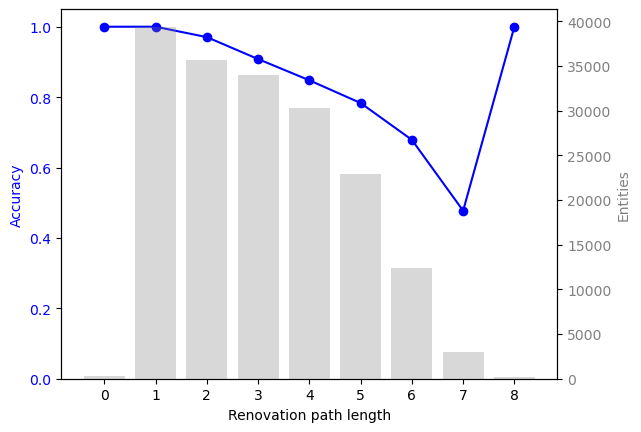

In [8]:
# plot accuracy and occurrences for each step
steps = [i for i in range(0, 10)]
steps_df = pd.DataFrame({
    "Accuracy": [results[f'step_{i}_accuracy'].mean() for i in steps],
    "Entities": [results[f'step_{i}_occurrences'].mean() for i in steps]
})
steps_df = steps_df.transpose()
display(steps_df)

FIRST_COLOR, SECOND_COLOR = 'blue', 'gray'
fig, ax1 = plt.subplots()
# Plot accuracies
ax1.plot(steps, steps_df.iloc[0], marker='o', label='Accuracy', color=FIRST_COLOR)
ax1.set_xticks(steps)
ax1.set_xlabel("Renovation path length")
ax1.set_ylabel("Accuracy", color=FIRST_COLOR)
ax1.set_ylim(0, 1.05)
ax1.tick_params(axis='y', labelcolor=FIRST_COLOR)

# Plot occurrences
ax2 = ax1.twinx()
ax2.bar(steps, steps_df.iloc[1], alpha=0.3, color=SECOND_COLOR)
ax2.set_ylabel("Entities", color=SECOND_COLOR)
ax2.tick_params(axis='y', labelcolor=SECOND_COLOR)

plt.show()